# ModernBERT PCL Detection (Trainer API) - Local

This notebook fine-tunes `answerdotai/ModernBERT-base` for SemEval Task 4 Subtask 1 using:
- `AutoModelForSequenceClassification`
- `Trainer`
- `TrainingArguments`

Validation/evaluation focuses on **macro F1** (`f1_macro`).


In [1]:
!pip install contractions python-dotenv huggingface_hub


In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = 'answerdotai/ModernBERT-base'
RUN_NAME = 'checkpoints/modernbert'
MAX_LENGTH = 256

DATA_ROOT='..'
TSV_PATH = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

os.makedirs(RUN_NAME, exist_ok=True)

print(f'RUN_NAME  : {RUN_NAME}')


RUN_NAME  : checkpoints/modernbert


In [5]:
def load_task1(train_path: str) -> pd.DataFrame:
    """
    Load Task 1 data and convert original labels to binary:
      0/1 -> 0 (No-PCL)
      2/3/4 -> 1 (PCL)
    """
    rows = []
    with open(train_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue

            par_id = parts[0]
            art_id = parts[1]
            keyword = parts[2]
            country = parts[3]
            text = parts[4]
            orig_label = parts[-1]
            label = 0 if orig_label in {'0', '1'} else 1

            rows.append(
                {
                    'par_id': str(par_id),
                    'art_id': art_id,
                    'keyword': keyword,
                    'country': country,
                    'text': text,
                    'label': label,
                    'orig_label': orig_label,
                }
            )

    return pd.DataFrame(
        rows,
        columns=['par_id', 'art_id', 'keyword', 'country', 'text', 'label', 'orig_label'],
    )

In [ ]:
# ============================================================
# Load + preprocess data (local module)
# ============================================================
df = load_task1(TSV_PATH)

def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(preprocess_text)

# Include keyword and country in model input text.
df['keyword'] = df['keyword'].fillna('').astype(str)
df['country'] = df['country'].fillna('').astype(str)
df['model_text'] = df['keyword'].str.strip() + ' [SEP] ' + df['country'].str.strip() + ' [SEP] ' + df['clean_text'].str.strip()

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))



Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official Train/Dev split + hard oversampling (8x positives)
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df = pd.read_csv(DEV_IDS_PATH, dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)

leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)
if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n = len(frame)
    n_pcl = int((frame['label'] == 1).sum())
    n_no_pcl = int((frame['label'] == 0).sum())
    ratio = f'1:{(n_no_pcl / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<16} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no_pcl:,} | ratio={ratio}')


describe_split('Train (before OS)', train_df)
describe_split('Dev', dev_df)

replicated_pcls = pd.concat([train_df[train_df['label'] == 1]] * 8, ignore_index=True)
train_df = pd.concat([train_df, replicated_pcls], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after OS)', train_df)


Train (before OS) -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev              -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after OS) -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1


In [8]:
# ============================================================
# Tokenization + Hugging Face Datasets
# ============================================================
train_hf = Dataset.from_pandas(
    train_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds = dev_hf.map(tokenize, batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_ds)
print(dev_ds)



Map: 100%|██████████| 2094/2094 [00:00<00:00, 21190.56 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 14727
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [9]:
# ============================================================
# Metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }


In [10]:
# ============================================================
# Model + TrainingArguments + Trainer
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

# Same core training setup as the example notebook, with batch size=4.
training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='epoch',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,
    warmup_steps=2000,
    lr_scheduler_type='cosine',
    adam_epsilon=1e-6,
    weight_decay=0.01,
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured.')


Loading weights: 100%|██████████| 136/136 [00:00<00:00, 527.49it/s, Materializing param=model.layers.21.mlp_norm.weight]     
ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer configured.


In [11]:
train_result = trainer.train()
train_result


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,0.298117,0.577251,0.737405,0.715109,0.768400
2,0.024970,0.972609,0.694805,0.788165,0.653818


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.79s/it]


TrainOutput(global_step=7364, training_loss=0.2581335261488401, metrics={'train_runtime': 885.0977, 'train_samples_per_second': 33.278, 'train_steps_per_second': 8.32, 'total_flos': 2011622014767372.0, 'train_loss': 0.2581335261488401, 'epoch': 2.0})

In [12]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Evaluation metrics:
  eval_loss: 0.9726
  eval_f1_macro: 0.6948
  eval_precision_macro: 0.7882
  eval_recall_macro: 0.6538
  eval_runtime: 14.6094
  eval_samples_per_second: 143.3320
  eval_steps_per_second: 35.8670
  epoch: 2.0000


              precision    recall  f1-score   support

      No-PCL     0.9328    0.9810    0.9563      1895
         PCL     0.6436    0.3266    0.4333       199

    accuracy                         0.9188      2094
   macro avg     0.7882    0.6538    0.6948      2094
weighted avg     0.9053    0.9188    0.9066      2094



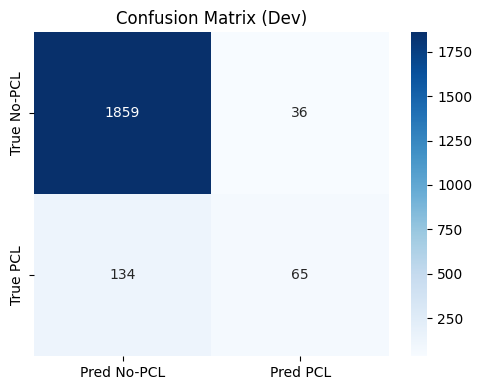

In [13]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev)')
plt.tight_layout()
plt.show()


In [14]:
BEST_MODEL_DIR = os.path.join(RUN_NAME, 'best')
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f'Saved best model and tokenizer to: {BEST_MODEL_DIR}')


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]

Saved best model and tokenizer to: checkpoints/modernbert/best
